# Exploratory Data Analysis of US Domestic Flights (2015–2017)

**Name:** Mobin Abedian  
**Dataset:** Airline Delay and Cancellation Data (2009–2018)  
**Source:** Kaggle Dataset by Yuanyu Wendy Mu

## Project Overview

This project performs an exploratory data analysis (EDA) on United States domestic flight data from 2015 to 2017. The analysis focuses on flight delays, cancellations, carrier performance, airport activity, and temporal patterns in air transportation.

The main goals of this project are:

- Understanding the structure and quality of the dataset
- Identifying patterns in delays and cancellations
- Comparing airlines and airports
- Exploring relationships between operational variables
- Producing visual and statistical summaries

The analysis is conducted using Python, pandas, matplotlib, and seaborn.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
pd.set_option("display.max_columns",None)
sb.set_style("whitegrid")

## Loading Flight Data

The dataset is provided as separate CSV files for each year.  
In this project, flight records from 2015, 2016, and 2017 are combined into a single dataframe for analysis.

In [19]:
df_2015 = pd.read_csv("../data/exploratory_data_analysis_of_airline_delays_and_cancellations/2015.csv",encoding='ISO-8859-1')
df_2016 = pd.read_csv("../data/exploratory_data_analysis_of_airline_delays_and_cancellations/2016.csv",encoding='ISO-8859-1')
df_2017 = pd.read_csv("../data/exploratory_data_analysis_of_airline_delays_and_cancellations/2017.csv",encoding='ISO-8859-1')

In [20]:
df = pd.concat(
    [df_2015,df_2016,df_2017],
    ignore_index=True
)

## Initial Data Inspection

In this section, we inspect the structure of the dataset using:

- `shape()` to view dataset dimensions
- `head()` to preview sample rows
- `info()` to inspect data types and missing values
- `describe()` to generate summary statistics for numerical variables

In [6]:
df.shape

(17111358, 28)

In [7]:
df.head()

,FL_DATE,OP_CARRIER,OP_CARRIER_FL_NUM,ORIGIN,DEST,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,CANCELLED,CANCELLATION_CODE,DIVERTED,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,AIR_TIME,DISTANCE,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,Unnamed: 27
0,2015-01-01,NK,195,MCO,FLL,2147,2143.0,-4.0,15.0,2158.0,2238.0,7.0,2250,2245.0,-5.0,0.0,NaN,0.0,63.0,62.0,40.0,177.0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-01,NK,197,LGA,FLL,1050,1104.0,14.0,20.0,1124.0,1354.0,9.0,1404,1403.0,-1.0,0.0,NaN,0.0,194.0,179.0,150.0,1076.0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015-01-01,NK,198,FLL,MCO,700,712.0,12.0,19.0,731.0,803.0,10.0,757,813.0,16.0,0.0,NaN,0.0,57.0,61.0,32.0,177.0,0.0,0.0,16.0,0.0,0.0,NaN
3,2015-01-01,NK,199,IAH,LAS,2240,2251.0,11.0,8.0,2259.0,2343.0,4.0,2356,2347.0,-9.0,0.0,NaN,0.0,196.0,176.0,164.0,1222.0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015-01-01,NK,200,IAH,ORD,623,620.0,-3.0,15.0,635.0,830.0,10.0,855,840.0,-15.0,0.0,NaN,0.0,152.0,140.0,115.0,925.0,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17111358 entries, 0 to 17111357
Data columns (total 28 columns):
 #   Column               Dtype  
---  ------               -----  
 0   FL_DATE              str    
 1   OP_CARRIER           str    
 2   OP_CARRIER_FL_NUM    int64  
 3   ORIGIN               str    
 4   DEST                 str    
 5   CRS_DEP_TIME         int64  
 6   DEP_TIME             float64
 7   DEP_DELAY            float64
 8   TAXI_OUT             float64
 9   WHEELS_OFF           float64
 10  WHEELS_ON            float64
 11  TAXI_IN              float64
 12  CRS_ARR_TIME         int64  
 13  ARR_TIME             float64
 14  ARR_DELAY            float64
 15  CANCELLED            float64
 16  CANCELLATION_CODE    str    
 17  DIVERTED             float64
 18  CRS_ELAPSED_TIME     float64
 19  ACTUAL_ELAPSED_TIME  float64
 20  AIR_TIME             float64
 21  DISTANCE             float64
 22  CARRIER_DELAY        float64
 23  WEATHER_DELAY        float64
 24  NAS_DEL

In [12]:
df.describe()

,OP_CARRIER_FL_NUM,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,CANCELLED,DIVERTED,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,AIR_TIME,DISTANCE,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,Unnamed: 27
count,1.711136e+07,1.711136e+07,1.688144e+07,1.688141e+07,1.687475e+07,1.687475e+07,1.686633e+07,1.686633e+07,1.711136e+07,1.686633e+07,1.683156e+07,1.711136e+07,1.711136e+07,1.711134e+07,1.683156e+07,1.683156e+07,1.711136e+07,3.057151e+06,3.057151e+06,3.057151e+06,3.057151e+06,3.057151e+06,0.0
mean,2.132214e+03,1.330184e+03,1.334193e+03,9.345809e+00,1.634567e+01,1.356037e+03,1.467802e+03,7.465423e+00,1.491334e+03,1.472350e+03,4.088201e+00,1.393449e-02,2.417634e-03,1.446642e+02,1.396208e+02,1.158210e+02,8.428433e+02,1.969906e+01,2.782354e+00,1.472193e+01,8.409136e-02,2.431198e+01,NaN
std,1.732574e+03,4.880600e+02,5.010820e+02,4.031023e+01,9.037232e+00,5.028149e+02,5.287876e+02,5.751211e+00,5.141182e+02,5.331055e+02,4.240217e+01,1.172191e-01,4.910997e-02,7.628076e+01,7.553560e+01,7.336019e+01,6.173912e+02,5.612670e+01,2.211699e+01,3.167008e+01,2.555855e+00,4.563615e+01,NaN
min,1.000000e+00,1.000000e+00,1.000000e+00,-2.340000e+02,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,-2.380000e+02,0.000000e+00,0.000000e+00,1.000000e+00,1.400000e+01,4.000000e+00,2.100000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,NaN
25%,7.250000e+02,9.150000e+02,9.170000e+02,-5.000000e+00,1.100000e+01,9.320000e+02,1.050000e+03,4.000000e+00,1.105000e+03,1.054000e+03,-1.400000e+01,0.000000e+00,0.000000e+00,8.800000e+01,8.400000e+01,6.100000e+01,3.860000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,NaN
50%,1.672000e+03,1.325000e+03,1.329000e+03,-2.000000e+00,1.400000e+01,1.341000e+03,1.507000e+03,6.000000e+00,1.520000e+03,1.511000e+03,-6.000000e+00,0.000000e+00,0.000000e+00,1.250000e+02,1.210000e+02,9.700000e+01,6.720000e+02,1.000000e+00,0.000000e+00,2.000000e+00,0.000000e+00,3.000000e+00,NaN
75%,3.063000e+03,1.735000e+03,1.742000e+03,6.000000e+00,1.900000e+01,1.756000e+03,1.913000e+03,9.000000e+00,1.920000e+03,1.917000e+03,7.000000e+00,0.000000e+00,0.000000e+00,1.770000e+02,1.720000e+02,1.470000e+02,1.084000e+03,1.800000e+01,0.000000e+00,1.800000e+01,0.000000e+00,3.000000e+01,NaN
max,9.855000e+03,2.359000e+03,2.400000e+03,2.755000e+03,2.250000e+02,2.400000e+03,2.400000e+03,4.140000e+02,2.400000e+03,2.400000e+03,2.189000e+03,1.000000e+00,1.000000e+00,7.180000e+02,7.840000e+02,7.230000e+02,4.983000e+03,2.142000e+03,1.934000e+03,1.605000e+03,8.270000e+02,1.756000e+03,NaN


## Variable Categorization

To better organize the exploratory analysis, the variables are grouped based on their semantic meaning and operational role in the dataset.

The main categories include:

- Flight identifiers
- Time-related variables
- Delay measurements
- Operational flight metrics
- Status indicators such as cancellations and diversions

This categorization simplifies later analysis and improves interpretability of tables and visualizations.

In [29]:
flight_identifier_columns = [
    "OP_CARRIER",
    "OP_CARRIER_FL_NUM",
    "ORIGIN",
    "DEST"
]

In [30]:
delay_columns = [
    "FL_DATE",
    "CRS_DEP_TIME",
    "DEP_TIME",
    "CRS_ARR_TIME",
    "ARR_TIME"
]

In [31]:
delay_columns = [
    "DEP_DELAY",
    "ARR_DELAY",
    "CARRIER_DELAY",
    "WEATHER_DELAY",
    "NAS_DELAY",
    "SECURITY_DELAY",
    "LATE_AIRCRAFT_DELAY"
]

In [32]:
operational_columns = [
    "DISTANCE",
    "AIR_TIME",
    "TAXI_IN",
    "TAXI_OUT",
    "ACTUAL_ELAPSED_TIME",
    "CRS_ELAPSED_TIME"
]

In [33]:
status_indicator_columns = [
    "CANCELLED",
    "DIVERTED"
]

In [21]:
df["Unnamed: 27"].value_counts(dropna=False)

Unnamed: 27
NaN    17111358
Name: count, dtype: int64

#  Missing Values and Data Quality

This section investigates missing values and data quality issues in the flight dataset.

Missing data are important in airline operational datasets because some variables are only available under specific conditions. For example, delay cause variables may only be populated for delayed flights, while arrival-related variables may be missing for cancelled flights.

Understanding these patterns is essential before performing further statistical analysis and visualization.

In [116]:
missing_counts = df.isnull().sum()

missing_percentages = (
    df.isnull().mean() * 100
)

missing_summary = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percentage": missing_percentages
})

missing_summary = missing_summary.sort_values(
    by="missing_percentage",
    ascending=False
)

In [118]:
missing_summary[
    missing_summary["missing_count"] > 0 
]

,missing_count,missing_percentage
CANCELLATION_CODE,16872920,98.606551
LATE_AIRCRAFT_DELAY,14054207,82.133791
SECURITY_DELAY,14054207,82.133791
CARRIER_DELAY,14054207,82.133791
WEATHER_DELAY,14054207,82.133791
NAS_DELAY,14054207,82.133791
ARR_DELAY,279795,1.635142
ACTUAL_ELAPSED_TIME,279795,1.635142
AIR_TIME,279795,1.635142
TAXI_IN,245031,1.431979


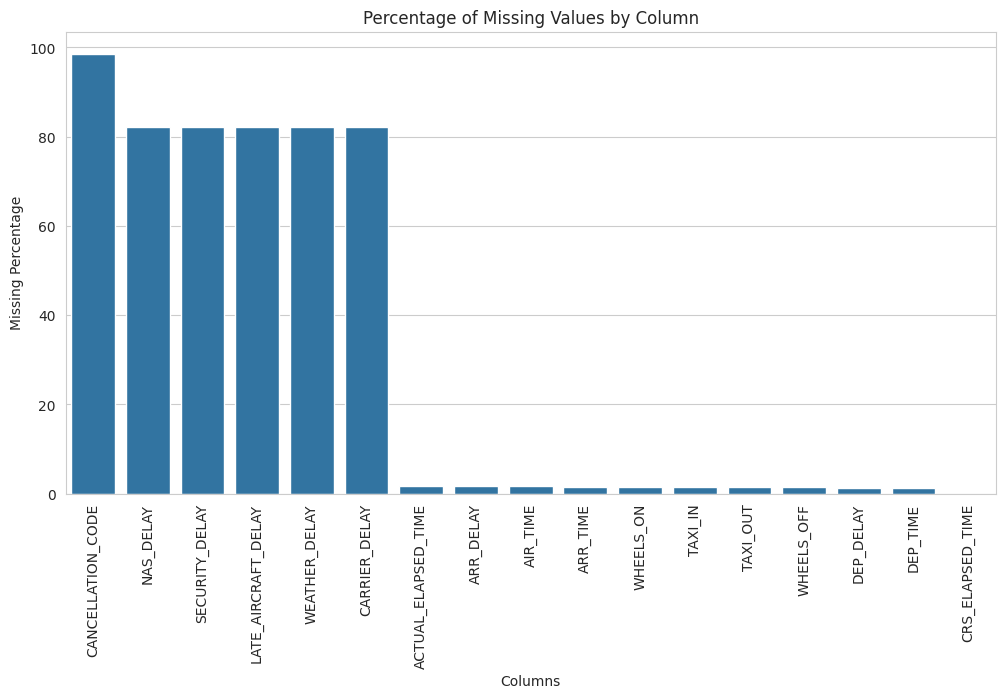

In [60]:
missing_plot = (
    missing_summary[
        missing_summary["missing_percentage"] > 0
    ]
    .sort_values(
        by="missing_percentage",
        ascending=False
    )
)

plt.figure(figsize=(12, 6))
sb.barplot(
    x=missing_plot.index,
    y=missing_plot["missing_percentage"]
)

plt.xticks(rotation=90)
plt.ylabel("Missing Percentage")
plt.xlabel("Columns")
plt.title("Percentage of Missing Values by Column")
plt.show()

## Relationship Between Cancellation Status and Cancellation Codes

The relationship between `CANCELLED` and `CANCELLATION_CODE` was examined to determine whether missing cancellation codes are meaningful.

The results show that cancellation codes are only present for cancelled flights and are missing for all non-cancelled flights. This indicates that the missing values in `CANCELLATION_CODE` are completely structural rather than accidental.

In [90]:
pd.crosstab(
    df["CANCELLED"],
    df["CANCELLATION_CODE"].isnull(),
    margins=True
)

CANCELLATION_CODE,False,True,All
CANCELLED,,,
0.0,0,16872920,16872920
1.0,238438,0,238438
All,238438,16872920,17111358


## Missing Arrival Delay Values

The relationship between flight cancellation status and missing arrival delay values was investigated.

All cancelled flights contain missing arrival delay values, which is expected because cancelled flights do not have actual arrival times. Additionally, a smaller number of non-cancelled flights also contain missing arrival delays, likely due to diverted flights or incomplete operational records.

In [91]:
pd.crosstab(
    df["CANCELLED"],
    df["ARR_DELAY"].isnull(),
    margins=True
)

ARR_DELAY,False,True,All
CANCELLED,,,
0.0,16831563,41357,16872920
1.0,0,238438,238438
All,16831563,279795,17111358


## Diverted Flights and Missing Arrival Information

The dataset was further examined to determine whether diverted flights contribute to missing arrival delay values.

The analysis shows that diverted flights are strongly associated with missing arrival-related variables. This suggests that missing arrival information is not entirely caused by cancellations and may also occur when flights are rerouted or incompletely reported.

In [95]:
pd.crosstab(
    df["DIVERTED"],
    df["ARR_DELAY"].isnull(),
    margins=True
)

ARR_DELAY,False,True,All
DIVERTED,,,
0.0,16831563,238426,17069989
1.0,0,41369,41369
All,16831563,279795,17111358


## Delay Cause Variables

Delay cause variables such as `WEATHER_DELAY`, `NAS_DELAY`, and `CARRIER_DELAY` contain a large number of missing values.

Further investigation shows that these variables are typically populated only for flights with significant delays. Flights with little or no delay usually do not contain detailed delay cause information.

In [93]:
pd.crosstab(
    df["ARR_DELAY"] > 0,
    df["WEATHER_DELAY"].isnull(),
    margins=True
)

WEATHER_DELAY,False,True,All
ARR_DELAY,,,
False,0,11195130,11195130
True,3057151,2859077,5916228
All,3057151,14054207,17111358


## Validation of Delay Cause Reporting

To validate the consistency of delay reporting, flights with arrival delays greater than or equal to 15 minutes were compared against the availability of delay cause variables.

The analysis revealed that nearly all significantly delayed flights contain at least one reported delay cause. Only a single inconsistent record was identified in the analyzed subset, suggesting that the dataset is highly consistent with respect to delay cause reporting.

In [99]:
delay_cause_columns = [
    "CARRIER_DELAY",
    "WEATHER_DELAY",
    "NAS_DELAY",
    "SECURITY_DELAY",
    "LATE_AIRCRAFT_DELAY"
]

df["TOTAL_REPORTED_DELAY"] = (
    df[delay_cause_columns]
    .fillna(0)
    .sum(axis=1)
)

df[
    (df["ARR_DELAY"] > 15) &
    (df["TOTAL_REPORTED_DELAY"] == 0)
].shape

(1, 28)